# Verification: Regional DSK model | Regional Govt. Module

This notebook recreates following climate shock scenarios of DSK model from Reissl et al (2025) on the regional version of the model.

> Objective: Test introduction of regional govt.

|Scenario                    |flags                                             |
|----------------------------|--------------------------------------------------|
|Baseline (No shocks)        |flag_shockexperiment = 0;                         |
|Capital Stock Shocks (CS)   | flag_shockexperiment = 1; flag_capshocks = 1;    |
|Productivity Shocks (LS+EF) | flag_shockexperiment = 1; flag_prodshocks = 1;   |

In [2]:
from pathlib import Path
import sys

# Load reusable reader from scripts/read_batch_runs.py
project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import plotly.graph_objects as go
import seaborn as sns


import plotly.graph_objects as go
from plotly.subplots import make_subplots

import scripts.read_batch_runs as _rbr
importlib.reload(_rbr)

from scripts.read_batch_runs import (
    load_simulation_results_matrix,
    check_regional_consistency,
)
from scripts.visualise_shocks import *
from scripts.compute_macros import *
from scripts.lineplots import *

## Define PATH

In [4]:
# define paths to experiment runs.
PATHS = {
    'hrhs' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/RegGovt_uniformshock0"),
    'dsk_sfc' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/dsk_sfc")
    }
OUTPUT = Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/figures/RegGovt/figures/")
OUTPUT.mkdir(parents=True, exist_ok=True)
# load simulation result matrices
sim_matrix = {}
for PATH in PATHS.keys():
    sim_matrix[PATH] = load_simulation_results_matrix(PATHS[PATH])

Found 3 scenario candidate folders under /Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/RegGovt_uniformshock0
Scenario 1: run_folders=50, max_run=50, macro_files_loaded=50, region_files_loaded=200, max_region=4, shock_files_loaded=0
  Scenario 1: saved to scenario_1.csv.gz
Column count mismatch: data_cols=76, yaml_cols=83.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=76, yaml_cols=83.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=76, yaml_cols=83.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, yaml_cols=55.
Column count mismatch: data_cols=47, ya

In [5]:
# Extract simulation results
scenario_results = {}
for sim in sim_matrix.keys():
    for scenario_num in sim_matrix[sim].scenario.unique():
        scenario_results[f"{sim}_{scenario_num}"] = sim_matrix[sim].loc[sim_matrix[sim].scenario == scenario_num]
        

## Compute Macros

In [6]:
def compare_scenarios(df_a, df_b, metric_a, metric_b=None, t_min=200, label_a="DSK", label_b="R-DSK", alpha=0.05, region="macro"):
    """Compare a metric between two scenario DataFrames using Welch's t-test.

    Observations are first averaged per Monte Carlo run (over t > t_min),
    so each run contributes exactly one independent data point to the test.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``, and ``metric``.
    metric_a : str
        Column name from df_a to compare (e.g. 'Unemployment', 'GDP_r_growth').
    metric_b : str
        Column name from  df_b to compare (e.g. 'Unemployment', 'GDP_r_growth').
    t_min : int, default 200
        Only include observations with t > t_min before averaging.
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    if metric_b is None:
        metric_b = metric_a
        
    # Filter to macro region if multiple regions present
    if "region" in df_a.columns and df_a["region"].nunique() > 1:
        df_a = df_a[df_a["region"] == region]
    if "region" in df_b.columns and df_b["region"].nunique() > 1:
        df_b = df_b[df_b["region"] == region]

    # Aggregate to run-level means (one independent observation per run)
    a = (
        df_a.loc[df_a["t"] > t_min, ["run", metric_a]]
        .groupby("run")[metric_a].mean()
        .dropna()
    )
    b = (
        df_b.loc[df_b["t"] > t_min, ["run", metric_b]]
        .groupby("run")[metric_b].mean()
        .dropna()
    )

    print(f"Metric : {metric_a} ({label_a}) and {metric_b} ({label_b})  (t > {t_min},  aggregated to run-level means)")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    # Welch's t-test on run-level means
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal means across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")

    # ── Print table ─────────────────────────────────────────────────────────
    def _sig_star(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    ratio = b.mean() / a.mean()
    col_width = 22
    metric_display = metric_a if metric_a == metric_b else f"{metric_a}/{metric_b}"
    col_label = f"{label_b} / {label_a}"
    header_parts = [f"{'Metric':>25s}", f"{col_label:^{col_width}s}"]
    sep = "  ".join(["-" * 25, "-" * col_width])
    star = _sig_star(p_value)
    cell = f"{ratio:.4f} (t={t_stat:+.2f}){star}"

    print()
    print("  ".join(header_parts))
    print(sep)
    print("  ".join([f"{metric_display:>25s}", f"{cell:^{col_width}s}"]))
    print(sep)
    print(f"\nRatio = {label_b} / {label_a}  (run-level means, t > {t_min})")
    print(f"Significance: * p<0.05, ** p<0.01, *** p<0.001")
    print()


def compare_crisis_likelihood(df_a, df_b, t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="HRHS", alpha=0.05):
    """Compare per-run crisis likelihood between two scenario DataFrames.

    For each run, crisis likelihood = proportion of quarters (t > t_min)
    where GDP_r_growth < threshold. The resulting per-run likelihoods are
    then compared with Welch's t-test, giving one independent observation
    per Monte Carlo run.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``,
        and ``GDP_r_growth``.
    t_min : int, default 200
        Only include observations with t > t_min.
    threshold : float, default -5.0
        Crisis threshold in percent (Lamperti et al. 2018: -5.0).
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    def _run_level_likelihood(df):
        # Filter to macro region if multiple regions present
        if "region" in df.columns and df["region"].nunique() > 1:
            df = df[df["region"] == "macro"]

        work = df.loc[df["t"] > t_min, ["run", "GDP_r_growth"]].copy()
        valid = work["GDP_r_growth"].notna()

        # Binary crisis flag per row
        work["_crisis"] = np.where(valid, (work["GDP_r_growth"] < threshold).astype(int), np.nan)

        # Per-run likelihood = crisis quarters / valid quarters
        obs   = work[valid].groupby("run")["_crisis"].count()
        crises = work[valid].groupby("run")["_crisis"].sum()
        return (crises / obs.replace(0, np.nan)).astype(float).dropna()

    a = _run_level_likelihood(df_a)
    b = _run_level_likelihood(df_b)

    print(f"Crisis likelihood  (GDP_r_growth < {threshold}%,  t > {t_min})")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal crisis likelihood across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")
    print()


In [7]:
for scenario in scenario_results.keys():
    #  Compute unemployment
    scenario_results[scenario]['Unemployment'] = (1 - scenario_results[scenario].EmploymentRate) * 100
    # Compute GDP volatility
    scenario_results[scenario]['GDP_r_volatility'] = compute_GDP_r_volatility(scenario_results[scenario])
    #  Compute Output Growth Rate
    scenario_results[scenario]['GDP_r_growth'] = compute_gdp_r_growth(scenario_results[scenario])

/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_30985/1391837744.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['Unemployment'] = (1 - scenario_results[scenario].EmploymentRate) * 100
/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_30985/1391837744.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['GDP_r_volatility'] = compute_GDP_r_volatility(scenario_results[scenario])


In [8]:
for scenario in scenario_results.keys():
    #  Compute Real GDP (log-n)
    scenario_results[scenario]['GDP_r_ln'] = np.log(scenario_results[scenario]['GDP_r'])




/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_30985/473490794.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['GDP_r_ln'] = np.log(scenario_results[scenario]['GDP_r'])


In [9]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="Unemployment")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="GDP_r_volatility")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="GDP_r_growth")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="UnemploymentBenefit", metric_b="RegGov_SP")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="Deficit", metric_b="Deficit")

     #  Compute Crisis Likelihood
compare_crisis_likelihood(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="R-DSK", alpha=0.05)

Metric : Unemployment (DSK) and Unemployment (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=4.7049  std=0.2257  n_runs=50
  R-DSK       mean=4.6954  std=0.2337  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.2070
    p-value     : 8.3646e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
             Unemployment     0.9980 (t=+0.21)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r_volatility (DSK) and GDP_r_volatility (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=8.2887  std=0.6299  n_runs=50
  R-DSK       mean=8.2326  std=0.6268  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.4462
    p-value     : 6.5644e-01
    Significant : No (α = 0.05)

                   Metric       R-D

In [10]:
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="Unemployment")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="GDP_r_volatility")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="GDP_r_growth")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="UnemploymentBenefit", metric_b="RegGov_SP")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="Deficit", metric_b="Deficit")
     #  Compute Crisis Likelihood
compare_crisis_likelihood(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="R-DSK", alpha=0.05)

Metric : Unemployment (DSK) and Unemployment (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=4.5489  std=0.1858  n_runs=50
  R-DSK       mean=4.5188  std=0.1945  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.7925
    p-value     : 4.3001e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
             Unemployment     0.9934 (t=+0.79)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r_volatility (DSK) and GDP_r_volatility (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=8.5694  std=0.6242  n_runs=50
  R-DSK       mean=8.5485  std=0.7060  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.1571
    p-value     : 8.7546e-01
    Significant : No (α = 0.05)

                   Metric       R-D

/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_30985/770859331.py:48: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)


In [11]:
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="Unemployment")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="GDP_r_volatility")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="GDP_r_growth")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="UnemploymentBenefit", metric_b="RegGov_SP")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="Deficit", metric_b="Deficit")
     #  Compute Crisis Likelihood
compare_crisis_likelihood(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="R-DSK", alpha=0.05)

Metric : Unemployment (DSK) and Unemployment (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=4.5187  std=0.2035  n_runs=50
  R-DSK       mean=4.5013  std=0.2577  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.3752
    p-value     : 7.0835e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
             Unemployment     0.9961 (t=+0.38)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r_volatility (DSK) and GDP_r_volatility (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=8.2740  std=0.6003  n_runs=50
  R-DSK       mean=8.3515  std=0.5982  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.6468
    p-value     : 5.1930e-01
    Significant : No (α = 0.05)

                   Metric       R-

/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_30985/770859331.py:48: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)


Metric : GDP_r_growth (DSK) and GDP_r_growth (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=1.1078  std=0.0554  n_runs=50
  R-DSK       mean=1.1131  std=0.0729  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.4083
    p-value     : 6.8394e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
             GDP_r_growth     1.0048 (t=-0.41)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : UnemploymentBenefit (DSK) and RegGov_SP (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=nan  std=nan  n_runs=0
  R-DSK       mean=nan  std=nan  n_runs=0

  Welch's t-test  (H0: equal means across runs)
    t-statistic : nan
    p-value     : nan
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
------------

## Compare Macro-level variables

### Real GDP

In [12]:
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}

PDF_PAGES = [
    None,                                       # page 1: all scenarios
    ["DSK: No Shock"],                          # page 2: dsk_sfc_1
    ["DSK: No Shock", "Reg DSK: No Shock"],     # page 3: dsk_sfc_1 + hrhs_1
    ["DSK: CS"],                                # page 4: dsk_sfc_2
    ["DSK: CS", "Reg DSK: CS"],                 # page 5: dsk_sfc_2 + hrhs_2
    ["DSK: LP + EF"],                           # page 6: dsk_sfc_3
    ["DSK: LP + EF", "Reg DSK: LP + EF"],       # page 7: dsk_sfc_3 + hrhs_3
]

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_ln",
    metric_label='ln',
    snap_ts=np.arange(200, 620, 20),
    title='Real GDP',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "GDP_r_ln_line.pdf",
    ymin=12.8, ymax=14
)

fig1

# fig1.write_image("../figures/verification/GDP_r_ln.pdf", width=750, height=500, scale=2)
# fig1.write_html("../figures/verification/GDP_r_ln.html", include_plotlyjs="cdn")

In [15]:
list(scenario_results["hrhs_2"]['GDP_r_ln'])

[12.439540895057092,
 12.415858879864569,
 12.333879370109123,
 12.275174716740626,
 12.238506643112695,
 12.233506525835327,
 12.238373241143206,
 12.400073771648893,
 12.417710848236554,
 12.446521234685083,
 12.444856797212372,
 12.448137769082283,
 12.447919583298665,
 12.45072678690885,
 12.453038465161084,
 12.453660117991701,
 12.438791952186717,
 12.4581633693706,
 12.457008843871979,
 12.46305126405514,
 12.466031434232121,
 12.470622761585151,
 12.450119017253007,
 12.41704188138409,
 12.425924285542738,
 12.463920275671786,
 12.478325000556431,
 12.480666832829623,
 12.48547223785689,
 12.48840283106516,
 12.49204958115981,
 12.495199079922433,
 12.497999026189959,
 12.484703947599565,
 12.484263039838613,
 12.44568465905041,
 12.4229690915728,
 12.41719243891307,
 12.42802703023908,
 12.447362280070008,
 12.458620277097896,
 12.477934370089876,
 12.486300258778934,
 12.456372906474845,
 12.442517915040067,
 12.444807684533158,
 12.449410812206798,
 12.445546649321214,
 12.4

In [251]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="GDP_r")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="GDP_r")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="GDP_r")


Metric : GDP_r (DSK) and GDP_r (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=698341.9075  std=26331.9787  n_runs=50
  R-DSK       mean=701285.3282  std=25960.5497  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.5629
    p-value     : 5.7481e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
                    GDP_r     1.0042 (t=-0.56)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r (DSK) and GDP_r (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=699654.1376  std=28430.1434  n_runs=50
  R-DSK       mean=702051.1550  std=20051.1767  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.4872
    p-value     : 6.2721e-01
    Significant : No (α = 0.05)

                   Metric       R

In [252]:




_df = scenario_results["hrhs_1"]

# Macro rows already aggregate across all regions; average over runs
agg = _df[_df['region'] == 'macro'].groupby('t')[['RegGov_Grant', 'RegGov_Revenue']].mean()

taxes = agg['RegGov_Revenue'] - agg['RegGov_Grant']

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=agg.index, y=taxes,
    name='Regional Tax Shares', stackgroup='one',
    fillcolor='#4472C4', line=dict(color='#4472C4', width=0)
))
fig.add_trace(go.Scatter(
    x=agg.index, y=agg['RegGov_Grant'],
    name='Central Govt. Transfers', stackgroup='one',
    fillcolor='#ED7D31', line=dict(color='#ED7D31', width=0)
))

# fig.update_yaxes(range=[0, 140000], title_text='Regional Govt. Revenue')


fig.update_xaxes(title_text='t')
fig.update_layout(
    # title='Regional Govt Revenue Components',
    height=500, width=1000,
    font=dict(size=16),
    legend=dict(orientation='h', yanchor='bottom', y=-0.25, xanchor='center', x=0.5),
    plot_bgcolor='white', paper_bgcolor='white'
)
fig


In [253]:

# Stacked area: regional govt expenditure components (EA, SP, other) — absolute levels
# with EmploymentRate overlay on secondary y-axis
# RegGov_Expenditure is only in per-region rows; sum across regions then average over runs
import plotly.graph_objects as go
from plotly.subplots import make_subplots

_df = scenario_results["hrhs_1"]
_reg = _df[_df['region'] != 'macro']

agg = (
    _reg.groupby(['run', 't'])[['RegGov_EA', 'RegGov_SP', 'RegGov_Expenditure']]
    .sum()
    .groupby('t')
    .mean()
)

fig2 = make_subplots(specs=[[{"secondary_y": True}]])


fig2.add_trace(go.Scatter(
    x=agg.index, y=agg['RegGov_SP'],
    name='Social Protection (SP)', stackgroup='one',
    fillcolor='#ffe699', line=dict(color='#ffe699', width=0)
), secondary_y=False)
fig2.add_trace(go.Scatter(
    x=agg.index, y=agg['RegGov_EA'],
    name='Economic Activity (EA)', stackgroup='one',
    fillcolor='#d1c7d1', line=dict(color='#d1c7d1', width=0)
), secondary_y=False)



# fig2.update_yaxes(range=[0, 140000], title_text='Regional Govt. Expenditure')

fig2.update_xaxes(title_text='t')
fig2.update_layout(
    # title='Regional Govt Revenue Components',
    height=500, width=1000,
    font=dict(size=16),
    legend=dict(orientation='h', yanchor='bottom', y=-0.25, xanchor='center', x=0.5),
    plot_bgcolor='white', paper_bgcolor='white'
)
fig2


In [254]:
# scenario_results["hrhs_1"]['Deficit']
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_h",
    metric_label='Networth of Households',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of Households',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=0, ymax=25000000,
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_h_line.pdf",
)

# fig1.write_image("../figures/verification/GDP_r_ln.pdf", width=750, height=500, scale=2)
# fig1.write_html("../figures/verification/GDP_r_ln.html", include_plotlyjs="cdn")
fig1

In [255]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="NW_1")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="NW_1")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="NW_1")

Metric : NW_1 (DSK) and NW_1 (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=298769.8256  std=44456.4041  n_runs=50
  R-DSK       mean=288824.2450  std=50046.7275  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 1.0506
    p-value     : 2.9604e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
                     NW_1     0.9667 (t=+1.05)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : NW_1 (DSK) and NW_1 (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=335398.9100  std=52065.6217  n_runs=50
  R-DSK       mean=337872.0117  std=59116.0536  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.2220
    p-value     : 8.2478e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK 

In [256]:

SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_1",
    metric_label='Networth of K-Firms',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of K-Firms',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=0, ymax=1500000,
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_1_line.pdf",
)

# fig1.write_html("../figures/verification/GDP_r_ln.html", include_plotlyjs="cdn")
fig1

In [257]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="NW_2")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="NW_2")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="NW_2")

Metric : NW_2 (DSK) and NW_2 (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=5506476.0702  std=375585.5019  n_runs=50
  R-DSK       mean=5568349.2657  std=437982.9687  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.7583
    p-value     : 4.5010e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
                     NW_2     1.0112 (t=-0.76)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : NW_2 (DSK) and NW_2 (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=5498145.0643  std=413333.8405  n_runs=50
  R-DSK       mean=5546251.1247  std=356920.4114  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.6229
    p-value     : 5.3481e-01
    Significant : No (α = 0.05)

                   Metric    

In [258]:
# scenario_results["hrhs_1"]['Deficit']
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_2",
    metric_label='Networth of C-Firms',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of C-Firms',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
        pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_2_line.pdf",
    # ymin=12.8, ymax=14
)

# fig1.write_image("../figures/verification/GDP_r_ln.pdf", width=750, height=500, scale=2)
# fig1.write_html("../figures/verification/GDP_r_ln.html", include_plotlyjs="cdn")
fig1

In [259]:

SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_gov_over_GDPn",
    metric_label='Networth of Central Government / GDP',
    snap_ts=np.arange(200, 620, 20),
    title='',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=-0.25, ymax=-0.14,
        pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_gov_over_GDP_line.pdf",
)

# fig1.write_html("../figures/verification/GDP_r_ln.html", include_plotlyjs="cdn")
fig1

In [260]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="NW_gov_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="NW_gov_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="NW_gov_over_GDPn")

Metric : NW_gov_over_GDPn (DSK) and NW_gov_over_GDPn (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=-0.2008  std=0.0123  n_runs=50
  R-DSK       mean=-0.1989  std=0.0155  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.6568
    p-value     : 5.1282e-01
    Significant : No (α = 0.05)

                   Metric       R-DSK / DSK      
-------------------------  ----------------------
         NW_gov_over_GDPn     0.9909 (t=-0.66)   
-------------------------  ----------------------

Ratio = R-DSK / DSK  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : NW_gov_over_GDPn (DSK) and NW_gov_over_GDPn (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=-0.1954  std=0.0142  n_runs=50
  R-DSK       mean=-0.1909  std=0.0118  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.7218
    p-value     : 8.8254e-02
    Significant : No (α = 0.05)

                   Me

#### Std. dev. of filtered Real GDP

In [193]:
def plot_boxplots(
    metric,
    scenario_names,
    labels=None,
    title="Standard deviation of filtered real GDP",
    colors=None,
    y_label="Std. Dev. of GDP_r",
    figsize=(6, 5.5),
    dpi=140,
    save_path=None,
):
    """Plot given metric as a notched Matplotlib box plot.

    Parameters
    ----------
    metric : dict
        Mapping scenario name -> pandas Series/array of metric values.
    scenario_names : list[str]
        Scenarios to plot in this order.
    labels : list[str] | None
        Display labels for x-axis. If None, scenario_names are used.
    title : str
        Figure title.
    colors : list[str] | dict[str, str] | None
        Box outline/median colors. If dict, keyed by scenario name.
    y_label : str
        Y-axis label.
    figsize : tuple[float, float]
        Figure size in inches.
    dpi : int
        Figure resolution.
    save_path : str | None
        Optional path to save the figure.
    """
    if labels is None:
        labels = scenario_names

    if len(labels) != len(scenario_names):
        raise ValueError("labels length must match scenario_names length")

    missing = [name for name in scenario_names if name not in metric]
    if missing:
        raise KeyError(f"Missing scenarios in gdp_r_std: {missing}")

    if colors is None:
        palette = ["#0B9E77", "#E41A1C", "#56B4E9"]
        color_list = [palette[i % len(palette)] for i in range(len(scenario_names))]
    elif isinstance(colors, dict):
        color_list = [colors[name] for name in scenario_names]
    else:
        if len(colors) != len(scenario_names):
            raise ValueError("colors length must match scenario_names length")
        color_list = list(colors)

    data = []
    for name in scenario_names:
        values = metric[name]
        if hasattr(values, "dropna"):
            values = values.dropna()
        data.append(np.asarray(values, dtype=float))

    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    bp = ax.boxplot(
        data,
        tick_labels=labels,
        notch=True,
        patch_artist=True,
        widths=0.75,
        showfliers=True,
        whis=1.5,
    )

    for i, box in enumerate(bp["boxes"]):
        box.set(facecolor="none", edgecolor=color_list[i], linewidth=1.5)

    for i, whisker in enumerate(bp["whiskers"]):
        whisker.set(color=color_list[i // 2], linewidth=1.3)

    for i, cap in enumerate(bp["caps"]):
        cap.set(color=color_list[i // 2], linewidth=1.3)

    for i, median in enumerate(bp["medians"]):
        median.set(color=color_list[i], linewidth=2.4)

    for i, flier in enumerate(bp["fliers"]):
        flier.set(
            marker="o",
            markersize=5,
            markerfacecolor=color_list[i],
            markeredgecolor=color_list[i],
            alpha=1.0,
        )

    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_facecolor("#ffffff")
    ax.grid(True, axis="both", alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='both')

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()

#### Avg. Annualized Real GDP Growth

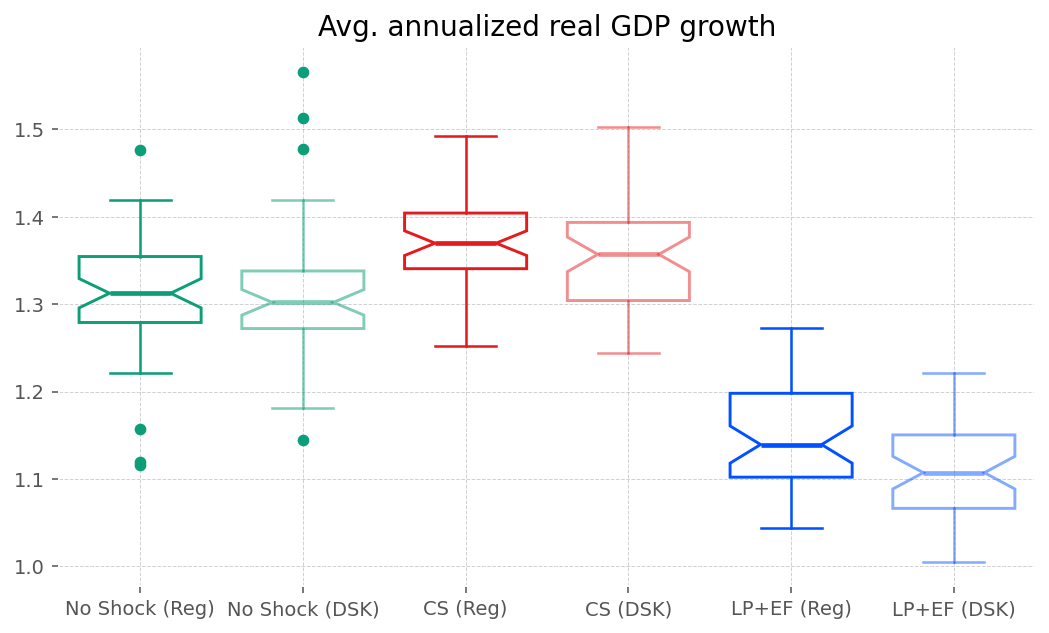

In [194]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()



plot_boxplots(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(9, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path=OUTPUT / "GDP_r_annualized_growth.pdf"
)

In [195]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="GDP_r_ln")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="GDP_r_ln")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="GDP_r_ln")


Metric : GDP_r_ln (DSK) and GDP_r_ln (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=13.4123  std=0.0363  n_runs=50
  R-DSK       mean=13.4165  std=0.0346  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.5944
    p-value     : 5.5360e-01
    Significant : No (α = 0.05)

Metric : GDP_r_ln (DSK) and GDP_r_ln (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=13.4141  std=0.0392  n_runs=50
  R-DSK       mean=13.4191  std=0.0316  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.6960
    p-value     : 4.8810e-01
    Significant : No (α = 0.05)

Metric : GDP_r_ln (DSK) and GDP_r_ln (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=13.3170  std=0.0354  n_runs=50
  R-DSK       mean=13.3322  std=0.0310  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -2.2906
    p-value     : 2.4132e-02
    Significant : Yes (α = 0.05)



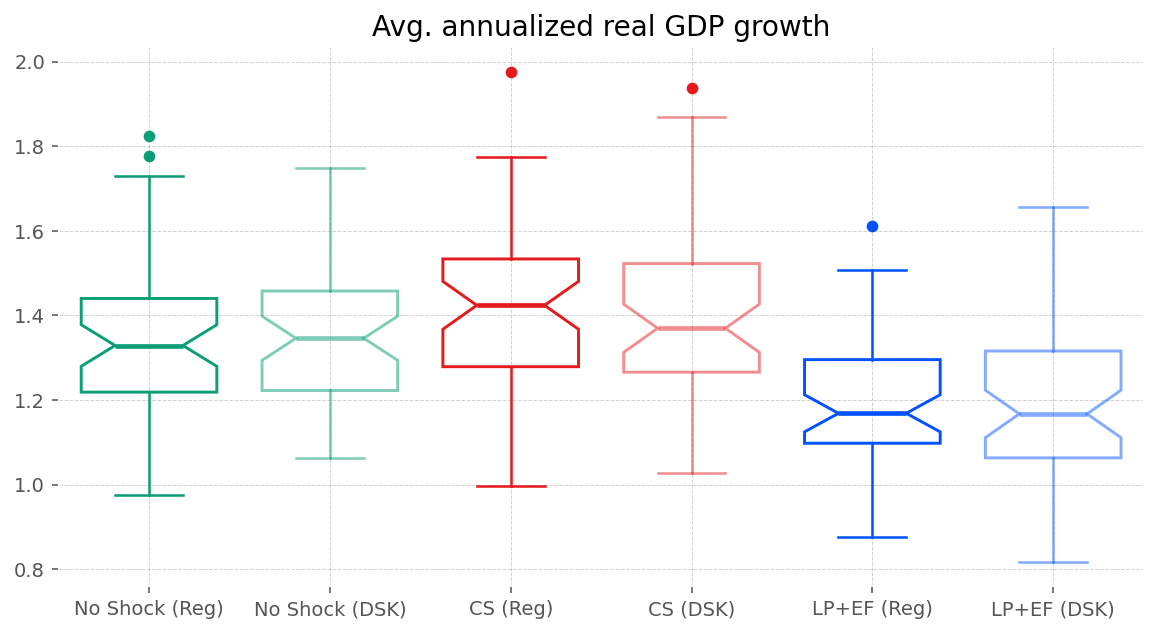

In [196]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(200, 300, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_boxplots(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path= OUTPUT / "GDP_r_annualized_growth_200-300.pdf",
)

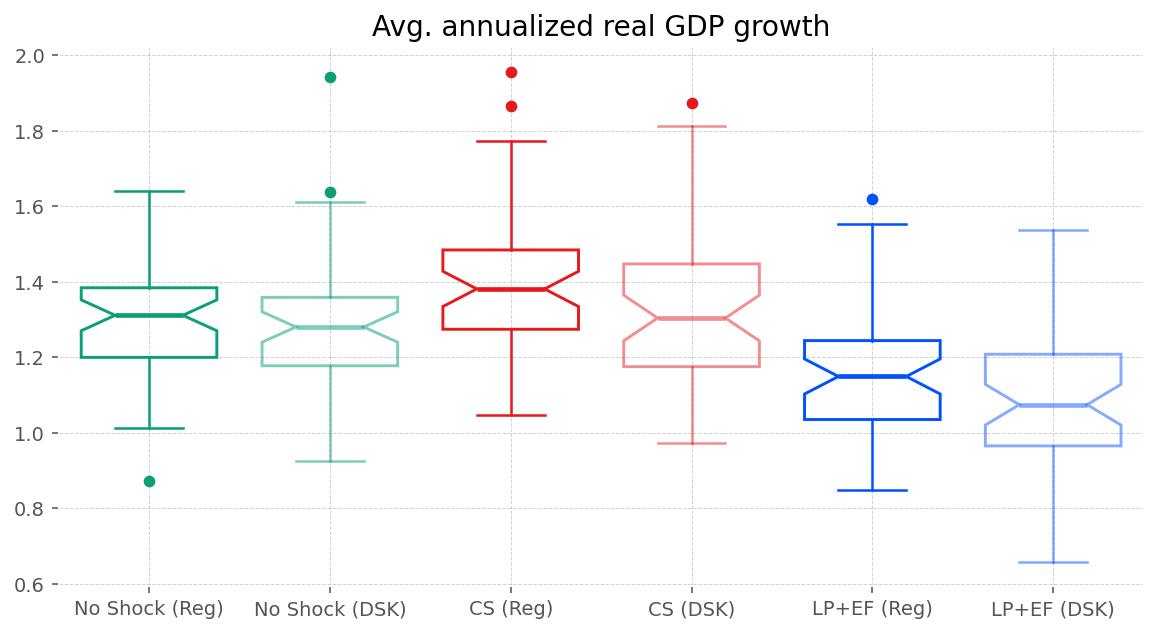

In [197]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(300, 400, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_boxplots(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path=OUTPUT / "GDP_r_annualized_growth_300-400.pdf",
)

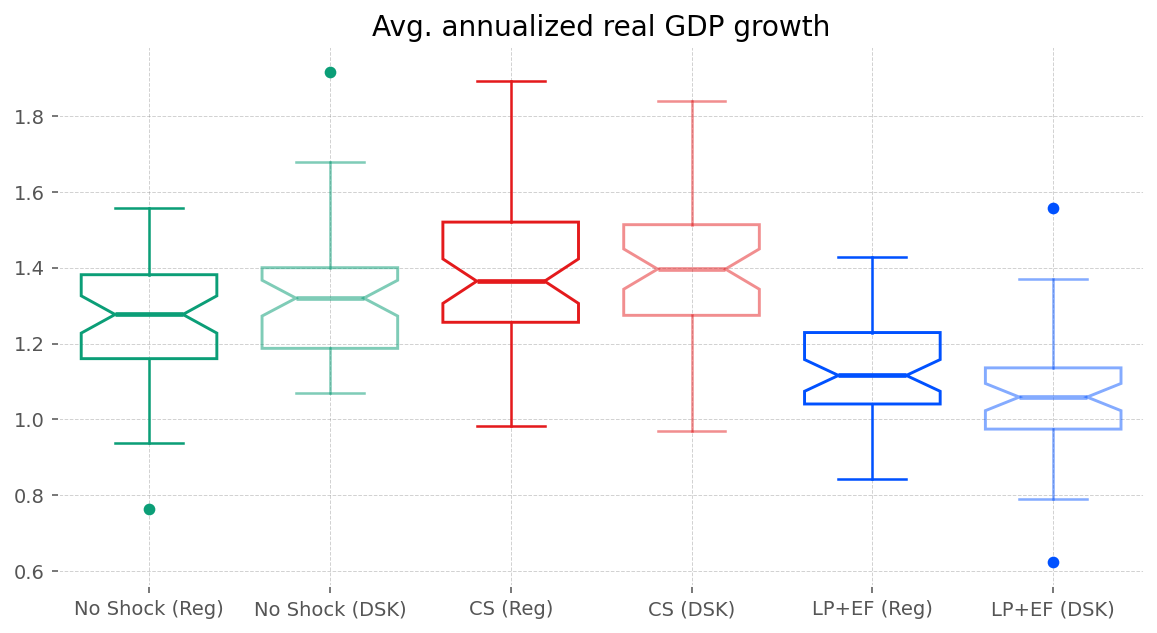

In [198]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(400, 500, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_boxplots(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path=OUTPUT / "GDP_r_annualized_growth_400-500.pdf",
)

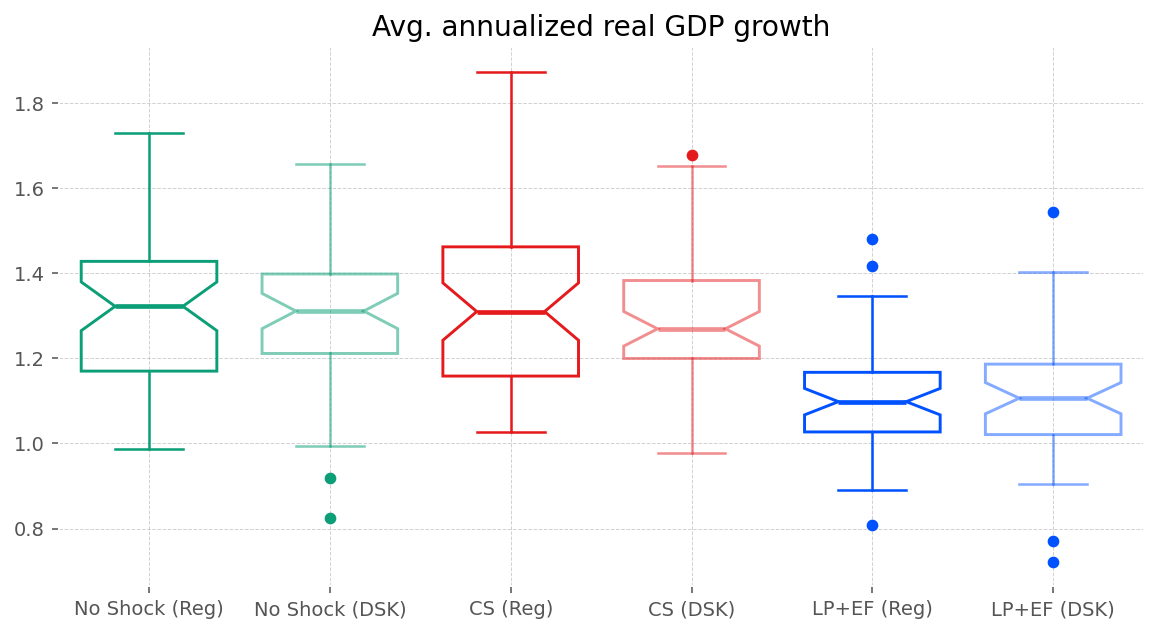

In [199]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(500, 600, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_boxplots(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path=OUTPUT/"GDP_r_annualized_growth_500-600.pdf",
)

### GDP Growth

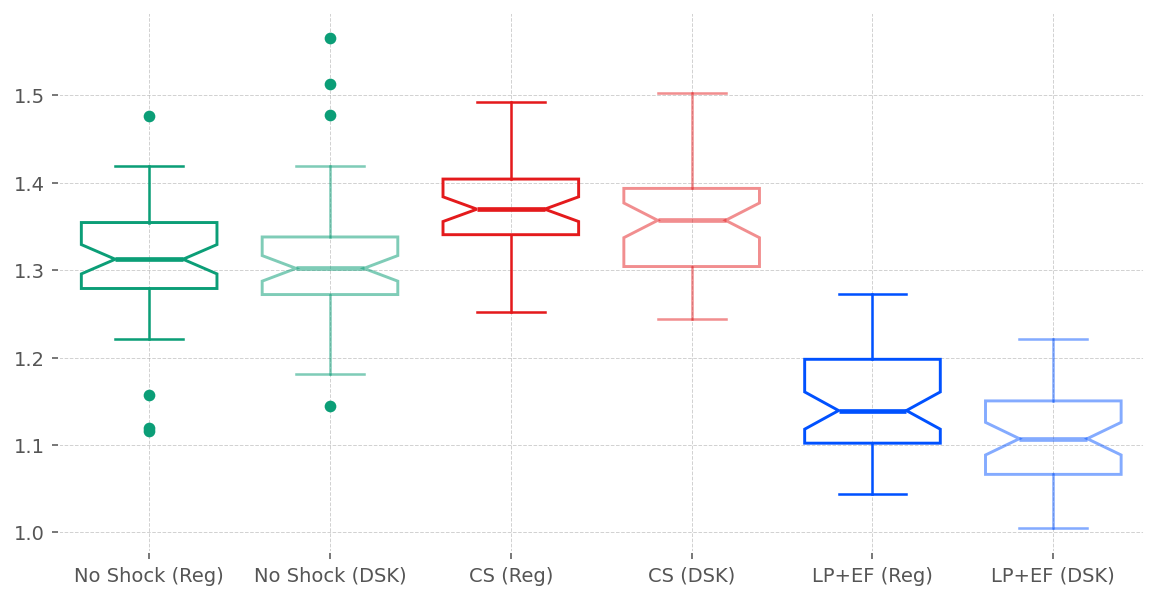

In [200]:
metric = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    metric[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()
        

plot_boxplots(
    metric=metric,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="",
    y_label='',
    save_path=OUTPUT/"GDP_r_growth.pdf",
)

In [201]:
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_growth",
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='Real GDP Growth',
    line_type='lines',
    ncol_legend=3,
    ymin=-15,
    ymax=20,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "GDP_r_growth_line.pdf",
)
fig1

# fig1.write_html("../figures/sprint4/GDP_r_growth_line.html", include_plotlyjs="cdn")

In [70]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="GDP_r_growth")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="GDP_r_growth")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="GDP_r_growth")

Metric : GDP_r_growth  (t > 200,  aggregated to run-level means)
  DSK         mean=1.3309  std=0.0882  n_runs=20
  HRHS        mean=1.4932  std=0.1185  n_runs=20

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -4.9172
    p-value     : 1.7187e-05
    Significant : Yes (α = 0.05)

Metric : GDP_r_growth  (t > 200,  aggregated to run-level means)
  DSK         mean=1.3804  std=0.0721  n_runs=20
  HRHS        mean=1.5178  std=0.1658  n_runs=20

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -3.3982
    p-value     : 1.6044e-03
    Significant : Yes (α = 0.05)

Metric : GDP_r_growth  (t > 200,  aggregated to run-level means)
  DSK         mean=1.1059  std=0.0492  n_runs=20
  HRHS        mean=1.3318  std=0.0904  n_runs=20

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -9.8183
    p-value     : 5.6694e-12
    Significant : Yes (α = 0.05)



### Bad debt as % of nominal GDP

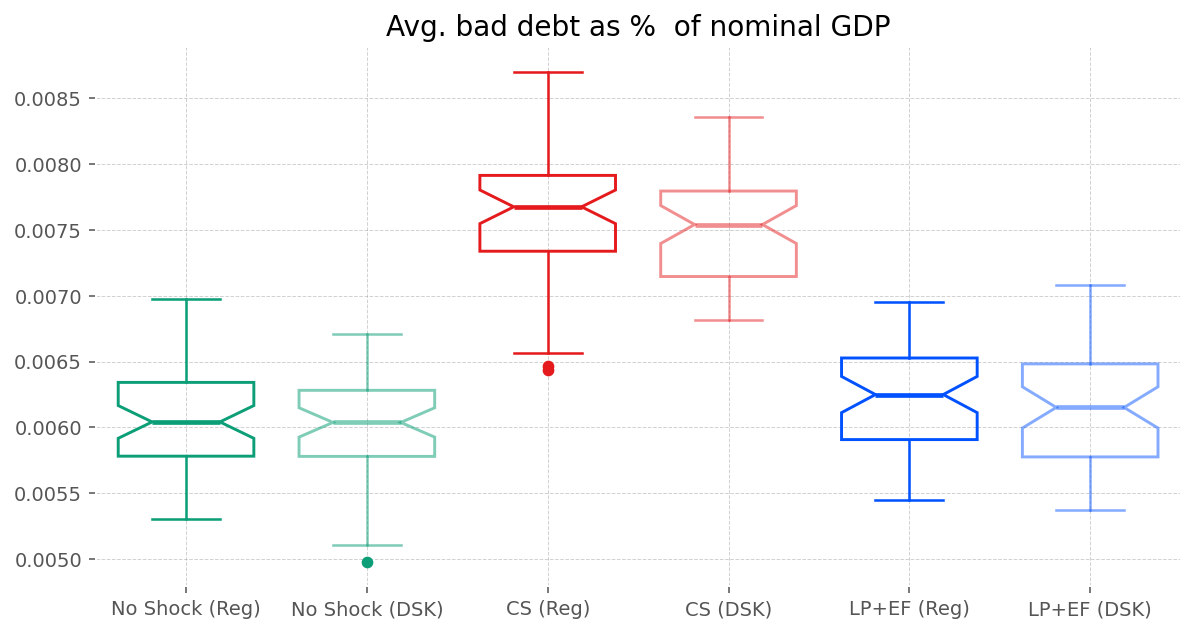

In [203]:
bad_debt_b_over_GDPn = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    bad_debt_b_over_GDPn[scenario] = temp_df.groupby(['run'])['baddebt_b_over_GDP'].mean()
        

plot_boxplots(
    metric=bad_debt_b_over_GDPn,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. bad debt as %  of nominal GDP",
    y_label='',
    save_path=OUTPUT/"baddebt_b_over_GDP.pdf",
)

In [209]:
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="baddebt_b_over_GDP",
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='baddebt_b_over_GDP',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=0.015,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "baddebt_line.pdf",
)
fig1

# fig1.write_html("../figures/sprint4/baddebt_b_over_GDP.html", include_plotlyjs="cdn")

In [205]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="baddebt_b_over_GDP")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="baddebt_b_over_GDP")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="baddebt_b_over_GDP")

Metric : baddebt_b_over_GDP (DSK) and baddebt_b_over_GDP (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=0.0060  std=0.0003  n_runs=50
  R-DSK       mean=0.0061  std=0.0004  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.7855
    p-value     : 4.3403e-01
    Significant : No (α = 0.05)

Metric : baddebt_b_over_GDP (DSK) and baddebt_b_over_GDP (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=0.0075  std=0.0004  n_runs=50
  R-DSK       mean=0.0076  std=0.0005  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.2459
    p-value     : 2.1579e-01
    Significant : No (α = 0.05)

Metric : baddebt_b_over_GDP (DSK) and baddebt_b_over_GDP (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=0.0061  std=0.0004  n_runs=50
  R-DSK       mean=0.0062  std=0.0004  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.8444
    p-value     : 4.0050e-01
    

### Number of C-Firms failure

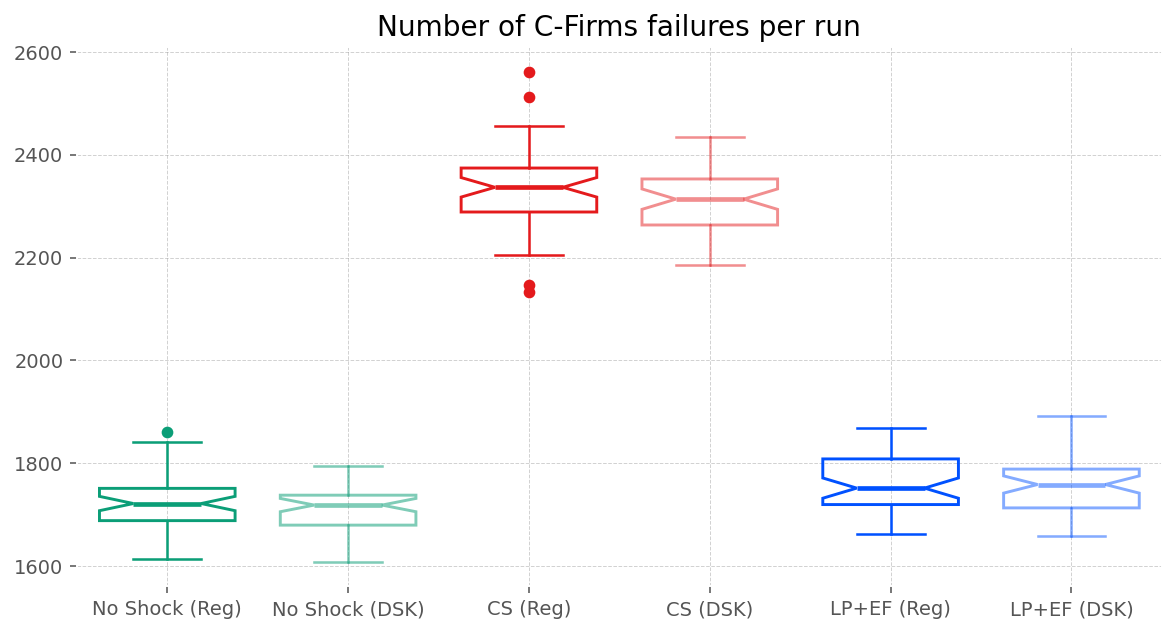

In [207]:
Exiting_CFirms = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    Exiting_CFirms[scenario] = temp_df.groupby(['run'])['Exiting_C-Firms'].sum()
        

plot_boxplots(
    metric=Exiting_CFirms,
    scenario_names=["hrhs_1", "dsk_sfc_1", 
                    "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"
                    ],
    labels=["No Shock (Reg)", "No Shock (DSK)", 
            "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", 
            "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"
            ],
    figsize=(10, 5),
    title="Number of C-Firms failures per run",
    y_label='',
    save_path=OUTPUT / "Exiting_C-Firms.pdf",
)

In [208]:
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}

PDF_PAGES = [
    None,                                       # page 1: all scenarios
    ["DSK: No Shock"],                          # page 2: dsk_sfc_1
    ["DSK: No Shock", "Reg DSK: No Shock"],     # page 3: dsk_sfc_1 + hrhs_1
    ["DSK: CS"],                                # page 4: dsk_sfc_2
    ["DSK: CS", "Reg DSK: CS"],                 # page 5: dsk_sfc_2 + hrhs_2
    ["DSK: LP + EF"],                           # page 6: dsk_sfc_3
    ["DSK: LP + EF", "Reg DSK: LP + EF"],       # page 7: dsk_sfc_3 + hrhs_3
]

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric='Exiting_C-Firms',
    metric_label='Avg. Cfirms exiting per run',
    snap_ts=np.arange(200, 620, 20),
    title='Exiting_C-Firms',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=12,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "Exiting_C-Firms_line.pdf",
)
fig1

# fig1.write_html("../figures/verification/Exiting_C-Firms.html", include_plotlyjs="cdn")


In [ ]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="Exiting_C-Firms")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="Exiting_C-Firms")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="Exiting_C-Firms")

Metric : Exiting_C-Firms  (t > 200,  aggregated to run-level means)
  DSK         mean=4.2846  std=0.1158  n_runs=20
  HRHS        mean=4.2483  std=0.1446  n_runs=20

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.8779
    p-value     : 3.8552e-01
    Significant : No (α = 0.05)

Metric : Exiting_C-Firms  (t > 200,  aggregated to run-level means)
  DSK         mean=5.7784  std=0.1278  n_runs=20
  HRHS        mean=5.7022  std=0.1800  n_runs=20

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 1.5423
    p-value     : 1.3128e-01
    Significant : No (α = 0.05)

Metric : Exiting_C-Firms  (t > 200,  aggregated to run-level means)
  DSK         mean=4.3791  std=0.1469  n_runs=20
  HRHS        mean=4.3635  std=0.1472  n_runs=20

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.3361
    p-value     : 7.3864e-01
    Significant : No (α = 0.05)



### Unemployment

In [210]:
metric = "Unemployment"

SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}

PDF_PAGES = [
    None,                                       # page 1: all scenarios
    ["DSK: No Shock"],                          # page 2: dsk_sfc_1
    ["DSK: No Shock", "Reg DSK: No Shock"],     # page 3: dsk_sfc_1 + hrhs_1
    ["DSK: CS"],                                # page 4: dsk_sfc_2
    ["DSK: CS", "Reg DSK: CS"],                 # page 5: dsk_sfc_2 + hrhs_2
    ["DSK: LP + EF"],                           # page 6: dsk_sfc_3
    ["DSK: LP + EF", "Reg DSK: LP + EF"],       # page 7: dsk_sfc_3 + hrhs_3
]

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric=metric,
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title=metric,
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=10,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / f"{metric}.pdf",
)
fig1

# fig1.write_html("../figures/verification/Exiting_C-Firms.html", include_plotlyjs="cdn")


In [211]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="Unemployment")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="Unemployment")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="Unemployment")

Metric : Unemployment (DSK) and Unemployment (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=4.7049  std=0.2257  n_runs=50
  R-DSK       mean=4.6954  std=0.2337  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.2070
    p-value     : 8.3646e-01
    Significant : No (α = 0.05)

Metric : Unemployment (DSK) and Unemployment (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=4.5489  std=0.1858  n_runs=50
  R-DSK       mean=4.4605  std=0.1899  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 2.3528
    p-value     : 2.0631e-02
    Significant : Yes (α = 0.05)

Metric : Unemployment (DSK) and Unemployment (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=4.5187  std=0.2035  n_runs=50
  R-DSK       mean=4.4904  std=0.2055  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.6921
    p-value     : 4.9051e-01
    Significant : No (α = 0.05)



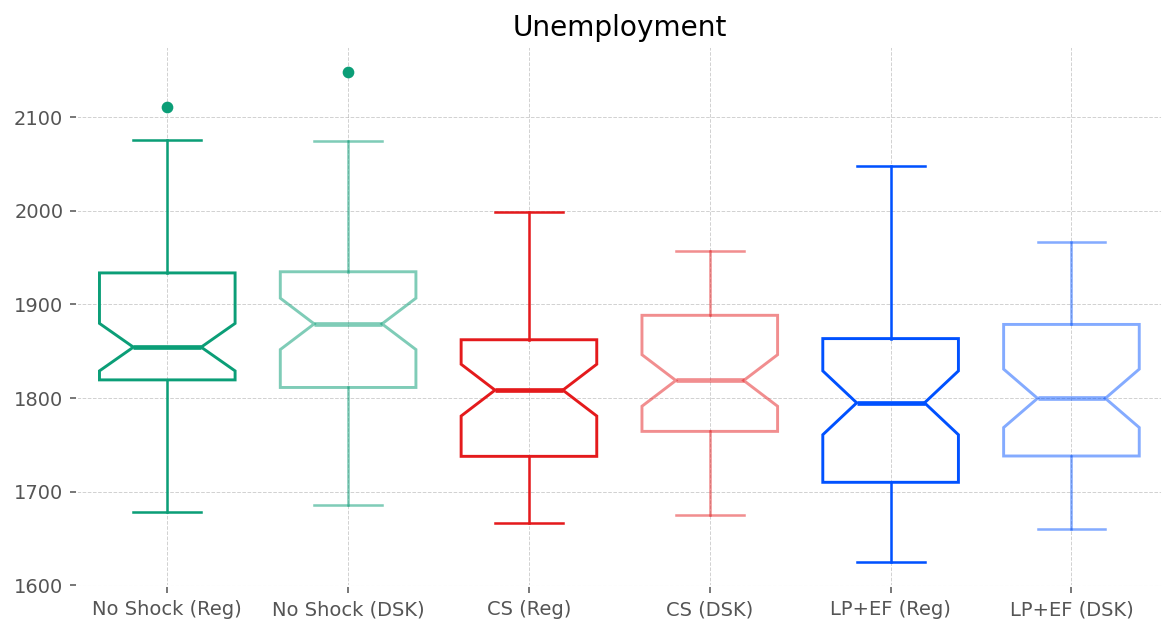

In [261]:
Unemployment = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    Unemployment[scenario] = temp_df.groupby(['run'])['Unemployment'].sum()
        

plot_boxplots(
    metric=Unemployment,
    scenario_names=["hrhs_1", "dsk_sfc_1", 
                    "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"
                    ],
    labels=["No Shock (Reg)", "No Shock (DSK)", 
            "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", 
            "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"
            ],
    figsize=(10, 5),
    title="Unemployment",
    y_label='',
    save_path=OUTPUT / "Unemployment_box.pdf",
)

### Deficit

In [214]:
scenario_results["hrhs_1"].loc[:,'deficit_over_gdpn'] = scenario_results["hrhs_1"]['Deficit']/scenario_results["hrhs_1"]['GDP_n']
scenario_results["hrhs_1"].loc[:,'deficit_over_gdpr'] = scenario_results["hrhs_1"]['Deficit']/scenario_results["hrhs_1"]['GDP_r']

scenario_results["dsk_sfc_1"].loc[:,'deficit_over_gdpn'] = scenario_results["dsk_sfc_1"]['Deficit']/scenario_results["dsk_sfc_1"]['GDP_n']
scenario_results["dsk_sfc_1"].loc[:,'deficit_over_gdpr'] = scenario_results["dsk_sfc_1"]['Deficit']/scenario_results["dsk_sfc_1"]['GDP_r']

/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_30668/1513304873.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results["hrhs_1"].loc[:,'deficit_over_gdpn'] = scenario_results["hrhs_1"]['Deficit']/scenario_results["hrhs_1"]['GDP_n']
/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_30668/1513304873.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results["hrhs_1"].loc[:,'deficit_over_gdpr'] = scenario_results["hrhs_1"]['Deficit']/scenario_results["hrhs_1"]['GDP_r']
/var/folders/1v/43

In [215]:

_hrhs = scenario_results["hrhs_1"][scenario_results["hrhs_1"]["region"] == "macro"].groupby("t")["Deficit"].mean()
_dsk  = scenario_results["dsk_sfc_1"][scenario_results["dsk_sfc_1"]["region"] == "macro"].groupby("t")["Deficit"].mean()

fig_deficit = go.Figure()
fig_deficit.add_trace(go.Scatter(
    x=_hrhs.index, y=_hrhs,
    name="Reg DSK: No Shock",
    line=dict(color="#009933", width=2)
))
fig_deficit.add_trace(go.Scatter(
    x=_dsk.index, y=_dsk,
    name="DSK: No Shock",
    line=dict(color="#00ff55", width=2, dash="dot")
))
fig_deficit.update_xaxes(title_text="t")
fig_deficit.update_yaxes(title_text="Deficit")
fig_deficit.update_layout(
    title="Deficit: Reg DSK vs DSK (No Shock)",
    height=500, width=1000,
    font=dict(size=16),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    plot_bgcolor="white", paper_bgcolor="white"
)
fig_deficit


In [216]:

_hrhs = scenario_results["hrhs_1"][scenario_results["hrhs_1"]["region"] == "macro"].groupby("t")["deficit_over_gdpn"].mean()
_dsk  = scenario_results["dsk_sfc_1"][scenario_results["dsk_sfc_1"]["region"] == "macro"].groupby("t")["deficit_over_gdpn"].mean()

fig_deficit = go.Figure()
fig_deficit.add_trace(go.Scatter(
    x=_hrhs.index, y=_hrhs,
    name="Reg DSK: No Shock",
    line=dict(color="#009933", width=2)
))
fig_deficit.add_trace(go.Scatter(
    x=_dsk.index, y=_dsk,
    name="DSK: No Shock",
    line=dict(color="#00ff55", width=2, dash="dot")
))
fig_deficit.update_xaxes(title_text="t")
fig_deficit.update_yaxes(title_text="Deficit")
fig_deficit.update_layout(
    title="Deficit: Reg DSK vs DSK (No Shock)",
    height=500, width=1000,
    font=dict(size=16),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    plot_bgcolor="white", paper_bgcolor="white"
)
fig_deficit


In [217]:

_hrhs = scenario_results["hrhs_1"][scenario_results["hrhs_1"]["region"] == "macro"].groupby("t")["deficit_over_gdpr"].mean()
_dsk  = scenario_results["dsk_sfc_1"][scenario_results["dsk_sfc_1"]["region"] == "macro"].groupby("t")["deficit_over_gdpr"].mean()

fig_deficit = go.Figure()
fig_deficit.add_trace(go.Scatter(
    x=_hrhs.index, y=_hrhs,
    name="Reg DSK: No Shock",
    line=dict(color="#009933", width=2)
))
fig_deficit.add_trace(go.Scatter(
    x=_dsk.index, y=_dsk,
    name="DSK: No Shock",
    line=dict(color="#00ff55", width=2, dash="dot")
))
fig_deficit.update_xaxes(title_text="t")
fig_deficit.update_yaxes(title_text="Deficit")
fig_deficit.update_layout(
    title="Deficit: Reg DSK vs DSK (No Shock)",
    height=500, width=1000,
    font=dict(size=16),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    plot_bgcolor="white", paper_bgcolor="white"
)
fig_deficit


In [218]:

_hrhs = scenario_results["hrhs_1"][scenario_results["hrhs_1"]["region"] == "macro"].groupby("t")["GB"].mean()
_dsk  = scenario_results["dsk_sfc_1"][scenario_results["dsk_sfc_1"]["region"] == "macro"].groupby("t")["GB"].mean()

fig_deficit = go.Figure()
fig_deficit.add_trace(go.Scatter(
    x=_hrhs.index, y=_hrhs,
    name="Reg DSK: No Shock",
    line=dict(color="#009933", width=2)
))
fig_deficit.add_trace(go.Scatter(
    x=_dsk.index, y=_dsk,
    name="DSK: No Shock",
    line=dict(color="#00ff55", width=2, dash="dot")
))
fig_deficit.update_xaxes(title_text="t")
fig_deficit.update_yaxes(title_text="Deficit")
fig_deficit.update_layout(
    title="Deficit: Reg DSK vs DSK (No Shock)",
    height=500, width=1000,
    font=dict(size=16),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    plot_bgcolor="white", paper_bgcolor="white"
)
fig_deficit


In [219]:

_hrhs = scenario_results["hrhs_1"][scenario_results["hrhs_1"]["region"] == "macro"].groupby("t")["NW_h"].mean()
_dsk  = scenario_results["dsk_sfc_1"][scenario_results["dsk_sfc_1"]["region"] == "macro"].groupby("t")["NW_h"].mean()

fig_deficit = go.Figure()
fig_deficit.add_trace(go.Scatter(
    x=_hrhs.index, y=_hrhs,
    name="Reg DSK: No Shock",
    line=dict(color="#009933", width=2)
))
fig_deficit.add_trace(go.Scatter(
    x=_dsk.index, y=_dsk,
    name="DSK: No Shock",
    line=dict(color="#00ff55", width=2, dash="dot")
))
fig_deficit.update_xaxes(title_text="t")
fig_deficit.update_yaxes(title_text="Deficit")
fig_deficit.update_layout(
    title="Deficit: Reg DSK vs DSK (No Shock)",
    height=500, width=1000,
    font=dict(size=16),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    plot_bgcolor="white", paper_bgcolor="white"
)
fig_deficit


### Sectoral net worth as % of nominal GDP

In [222]:
BG_COLOR = "white"  # use "rgba(0,0,0,0)" for transparent
GRID_COLOR = "rgba(128, 128, 128, 0.5)"

mean_sectoral_net_worth = {}
sectoral_net_worth = {}
sector_order = ["K-Firms", "C-Firms", "Households", "Banks", "Energy", "Govt."]

for scenario in ["dsk_sfc_1", "hrhs_1", ]:
    temp_df = scenario_results[scenario][scenario_results[scenario]["region"] == "macro"].copy()
    temp_df = temp_df[temp_df["t"] > 200].copy()
    for column in ["NW_1", "NW_2", "NW_h"]:
        temp_df[f"{column}_over_GDPn"] = temp_df[column] / (temp_df["GDP_n"] * 4)
    columns_dict = dict(
        zip(
            [
                "NW_1_over_GDPn",
                "NW_2_over_GDPn",
                "NW_h_over_GDPn",
                "NW_b_over_GDPn",
                "NW_e_over_GDPn",
                "NW_gov_over_GDPn",
            ],
            sector_order,
        )
    )
    temp_df.rename(columns=columns_dict, inplace=True)
    sectoral_net_worth[scenario] = temp_df

# ["dsk_sfc_2", "dsk_sfc_3", "hrhs_2", "hrhs_3"]
# for scenario in ["hrhs_3", ]:
#     net_worth = {}
#     for sector in sector_order:
#         if scenario.startswith("dsk"):
#             baseline = "dsk_sfc_1"
#         elif scenario.startswith("hrhs"):
#             baseline = "hrhs_1"

#         scenario_pairs = sectoral_net_worth[scenario][["t", "run", sector]].rename(
#             columns={sector: "scenario_val"}
#         )
#         baseline_pairs = sectoral_net_worth[baseline][["t", "run", sector]].rename(
#             columns={sector: "baseline_val"}
#         )

#         paired = scenario_pairs.merge(baseline_pairs, on=["t", "run"], how="inner")
#         paired["diff"] = (paired["scenario_val"] - paired["baseline_val"]) * 100

#         diff_by_t = paired.groupby("t")["diff"]
#         mean_diff = diff_by_t.mean()
#         n = diff_by_t.count().replace(0, np.nan)
#         std_diff = diff_by_t.std(ddof=1)
#         se_diff = std_diff / np.sqrt(n)
#         ci95 = 1.96 * se_diff

#         net_worth[sector] = {
#             "mean": mean_diff,
#             "ci95": ci95,
#         }
#     mean_sectoral_net_worth[scenario] = net_worth


color_dict = dict(
    zip(
        sector_order,
        [
            dict(color="rgb(219, 161, 55)"),
            dict(color="rgb(110, 177, 228)"),
            dict(color="rgb(19, 155, 116)"),
            dict(color="rgb(238, 227, 97)"),
            dict(color="rgb(69, 155, 116)"),
            dict(color="rgb(48, 111, 173)"),
        ],
    )
)

for scenario in mean_sectoral_net_worth.keys():
    fig = go.Figure()
    ci_trace_indices = []

    # 1) Add all sector mean lines first (legend row 1)
    for sector in sector_order:
        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=mean_series.values,
                mode="lines",
                name=sector,
                line=color_dict[sector],
                legendgroup=f"line_{sector}",
                showlegend=True,
            )
        )

    # 2) Add all confidence bands second (legend row 2)
    for sector in sector_order:
        line_color = color_dict[sector]["color"]
        fill_color = line_color.replace("rgb(", "rgba(").replace(")", ", 0.25)")

        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        ci_series = mean_sectoral_net_worth[scenario][sector]["ci95"].reindex(mean_series.index).fillna(0)
        upper = mean_series + ci_series
        lower = mean_series - ci_series

        ci_group = f"ci_{sector}"

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=upper.values,
                mode="lines",
                line=dict(width=0),
                legendgroup=ci_group,
                showlegend=False,
                hoverinfo="skip",
            )
        )

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=lower.values,
                mode="lines",
                line=dict(width=0),
                fill="tonexty",
                fillcolor=fill_color,
                legendgroup=ci_group,
                name="(95% CI)",
                showlegend=True,
                hoverinfo="skip",
            )
        )
        fig.update_yaxes(range=[-4, 4])

    fig.update_layout(
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        width=1200,
        height=500,
        xaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.20,
            xanchor="center",
            x=0.5,
            traceorder="normal",
            groupclick="togglegroup",
            entrywidthmode="fraction",
            entrywidth=0.16,
            tracegroupgap=0,
        ),
        margin=dict(b=150),
        )

    # fig.write_image(f"../figures/verification/sectoral_NW_{scenario}.pdf", width=1600, height=1000, scale=2)
    # fig.write_html(f"../figures/verification/sectoral_NW_{scenario}.html", include_plotlyjs="cdn")
    fig

In [223]:
fig.show()

In [224]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="NW_1")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="NW_2")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="NW_h")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="NW_b_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="NW_e_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="NW_gov_over_GDPn")

TypeError: compare_scenarios() got an unexpected keyword argument 'metric'. Did you mean 'metric_a'?

In [225]:
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_1")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_2")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_h")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_b_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_e_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_gov_over_GDPn")

TypeError: compare_scenarios() got an unexpected keyword argument 'metric'. Did you mean 'metric_a'?

In [226]:
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_1")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_2")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_h")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_b_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_e_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_gov_over_GDPn")

TypeError: compare_scenarios() got an unexpected keyword argument 'metric'. Did you mean 'metric_a'?

### Emissions

In [227]:
Emiss_TOT = pd.DataFrame()
for scenario in ['hrhs_2', 'hrhs_3', 'dsk_sfc_2', 'dsk_sfc_3']:
    if scenario.startswith('hrhs'):
        baseline = 'hrhs_1'
    elif scenario.startswith('dsk'):
        baseline = 'dsk_sfc_1'
    Emiss_TOT[scenario] =  (scenario_results[scenario].groupby('t')['Emiss_TOT'].mean() - (scenario_results[baseline].groupby('t')['Emiss_TOT'].mean())) / scenario_results[baseline].groupby('t')['Emiss_TOT'].mean() * 100

In [228]:
def build_emissions_change_figure(
    scenario_results,
    scenarios,
    baseline,
    line_colors,
    band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
):
    fig = go.Figure()

    for scenario in scenarios:
        sc_df = scenario_results[scenario].loc[
            scenario_results[scenario]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]
        bl_df = scenario_results[baseline].loc[
            scenario_results[baseline]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]

        paired = sc_df.merge(bl_df, on=['t', 'run'], suffixes=('_sc', '_bl'))
        paired['diff_pct'] = (
            (paired['Emiss_TOT_bl'] - paired['Emiss_TOT_sc'])
            / paired['Emiss_TOT_sc'].abs()
            * 100
        )
        paired = paired[paired['t'] > t_min]

        diff_by_t = paired.groupby('t')['diff_pct']
        mean_diff = diff_by_t.mean()
        n = diff_by_t.count().replace(0, np.nan)
        std_diff = diff_by_t.std(ddof=1)
        ci95 = 1.96 * std_diff / np.sqrt(n)

        x = mean_diff.index.to_numpy()
        upper = (mean_diff + ci95).to_numpy()
        lower = (mean_diff - ci95).to_numpy()

        if scenario.endswith('2'):
            name = 'CS'
        elif scenario.endswith('3'):
            name = 'LP+EF'
        fig.add_trace(go.Scatter(
            x=x,
            y=mean_diff.to_numpy(),
            mode='lines',
            name=name,
            line=dict(color=line_colors[scenario], width=2),
        ))

        fig.add_trace(go.Scatter(
            x=np.concatenate([x, x[::-1]]),
            y=np.concatenate([upper, lower[::-1]]),
            fill='toself',
            fillcolor=band_colors[scenario],
            line=dict(width=0),
            hoverinfo='skip',
            showlegend=False,
            name=f'{scenario} 95% CI',
        ))

    fig.update_yaxes(range=[-10, 10], )

    fig.update_layout(
        width=800,
        height=500,
        title=title,
        xaxis_title='Timestep (t)',
        yaxis_title='Δ Emiss_TOT (%)',
        hovermode='x',
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        xaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        yaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        template='simple_white',
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=-0.2,
            yanchor='top',
        ),
        margin=dict(b=90),
    )

    return fig



In [229]:
line_colors = {
    'hrhs_2': 'rgb(220, 38, 38)',
    'hrhs_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'hrhs_2': 'rgba(220, 38, 38, 0.2)',
    'hrhs_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['hrhs_2', 'hrhs_3'],
    baseline='hrhs_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)

fig.write_image(OUTPUT / f"Emissions_hrhs.pdf", scale=1)
fig.show()

In [230]:
line_colors = {
    'dsk_sfc_2': 'rgb(220, 38, 38)',
    'dsk_sfc_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'dsk_sfc_2': 'rgba(220, 38, 38, 0.2)',
    'dsk_sfc_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['dsk_sfc_2', 'dsk_sfc_3'],
    baseline='dsk_sfc_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)
fig.write_image(OUTPUT / "Emissions_dsk.pdf", scale=1)
fig.show()

In [232]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric_a="Emiss_TOT")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric_a="Emiss_TOT")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric_a="Emiss_TOT")

Metric : Emiss_TOT (DSK) and Emiss_TOT (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=31274653.7348  std=3620946.4505  n_runs=50
  R-DSK       mean=30981331.3702  std=3395710.6772  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.4178
    p-value     : 6.7699e-01
    Significant : No (α = 0.05)

Metric : Emiss_TOT (DSK) and Emiss_TOT (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=31297706.1690  std=3519857.7784  n_runs=50
  R-DSK       mean=30272180.9218  std=3014660.4304  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 1.5647
    p-value     : 1.2087e-01
    Significant : No (α = 0.05)

Metric : Emiss_TOT (DSK) and Emiss_TOT (R-DSK)  (t > 200,  aggregated to run-level means)
  DSK         mean=30937018.2814  std=3336496.2900  n_runs=50
  R-DSK       mean=30521213.7591  std=3387257.7557  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.6184
    p-value 

## Regional consistency

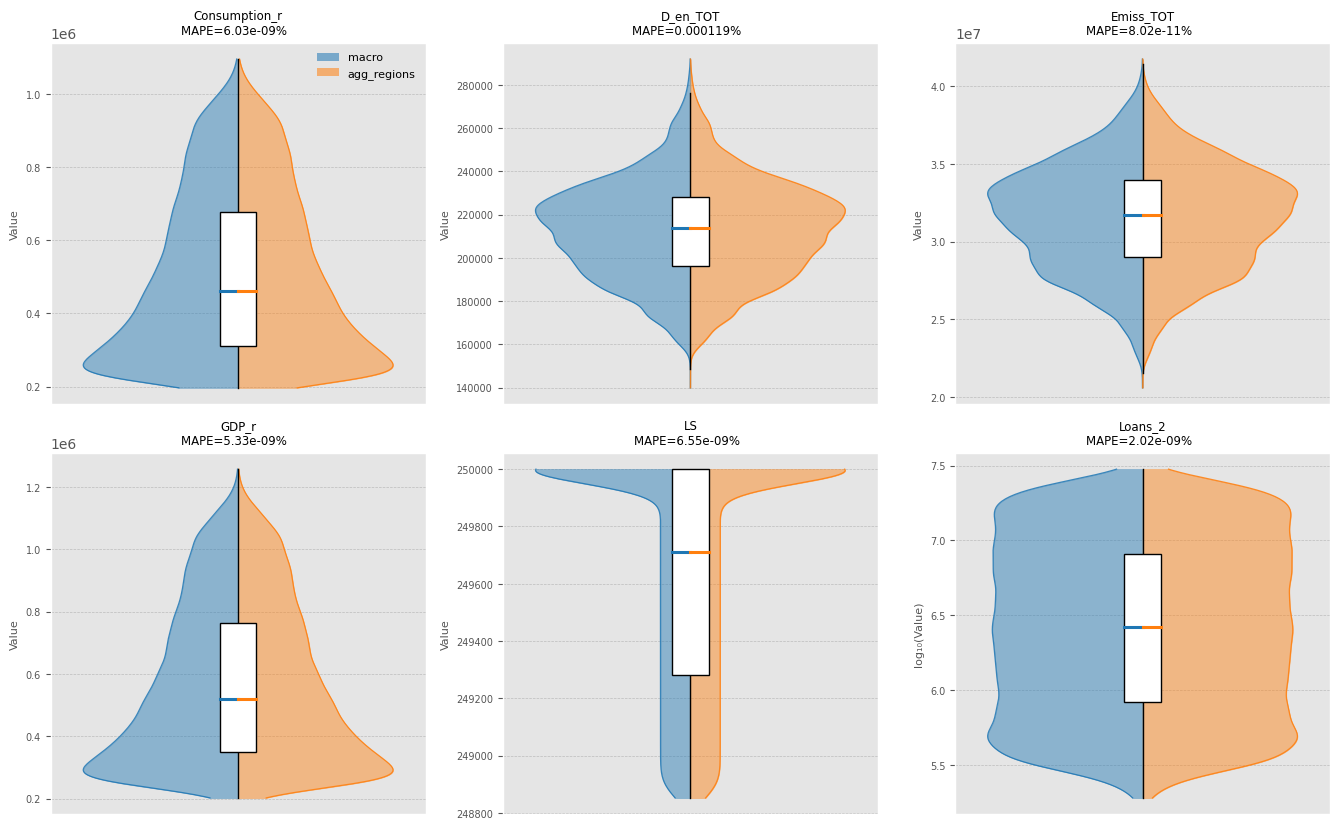

        variable  n_obs     mean_bias       mae      rmse  mean_abs_pct_err  \
0  Consumption_r  30000 -3.956202e-08  0.000025  0.000029      6.026917e-09   
1       D_en_TOT  30000 -9.205187e-05  0.250953  0.289570      1.192755e-04   
2      Emiss_TOT  30000  3.078096e-08  0.000025  0.000029      8.017400e-11   
3          GDP_r  30000 -1.616291e-07  0.000025  0.000029      5.326374e-09   
4             LS  30000 -1.011099e-06  0.000016  0.000023      6.550948e-09   
5        Loans_2  30000  1.619851e-08  0.000025  0.000029      2.022925e-09   

   max_abs_pct_err  corr  welch_t_pvalue  cohens_d     ks_pvalue  close_ratio  \
0     2.522111e-08   1.0             1.0 -0.001373  1.000000e+00          1.0   
1     3.058395e-04   1.0             1.0 -0.000318  1.000000e+00          1.0   
2     2.222610e-10   1.0             1.0  0.001068  1.000000e+00          1.0   
3     2.377889e-08   1.0             1.0 -0.005607  1.000000e+00          1.0   
4     2.002168e-08   1.0             1.0 

In [233]:


check_regional_consistency(
    scenario_results['hrhs_1'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'LS', 
    'Emiss_TOT',
    'Consumption_r',
    'Loans_2', 'D_en_TOT'],
    },
    output = OUTPUT / "regional_consistency_NoShock.pdf"
)

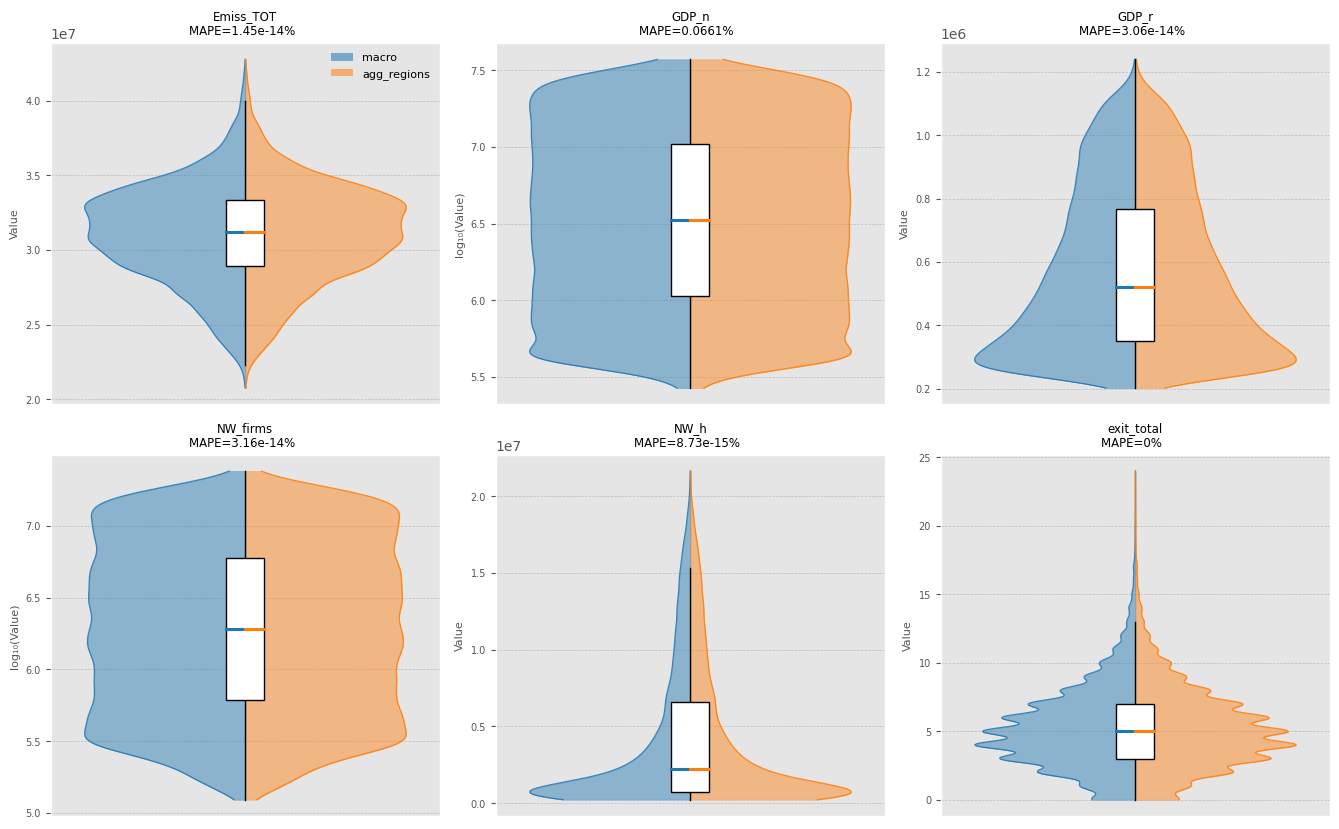

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  30000  4.061808e-10  4.479662e-09  6.121919e-09   
1       GDP_n  30000 -5.136106e+03  5.136108e+03  9.063589e+03   
2       GDP_r  30000  1.266987e-12  1.690409e-10  2.309056e-10   
3    NW_firms  30000  7.316412e-11  1.252898e-09  2.443162e-09   
4        NW_h  30000  6.065335e-11  3.191788e-10  7.349716e-10   
5  exit_total  30000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.446400e-14     1.910619e-13   1.0         1.00000  0.066494   
1      6.611813e-02     3.320033e-01   1.0         0.93834 -0.687749   
2      3.055423e-14     3.933948e-13   1.0         1.00000  0.005487   
3      3.164692e-14     2.053966e-13   1.0         1.00000  0.029959   
4      8.730424e-15     8.930680e-14   1.0         1.00000  0.082806   
5      0.000000e+00     0.000000e+00   1.0         1.00000  0.000000   

   ks_pvalue  close_ratio  passe

In [234]:
check_regional_consistency(
    scenario_results['hrhs_2'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = OUTPUT / "regional_consistency_CS.pdf"
)

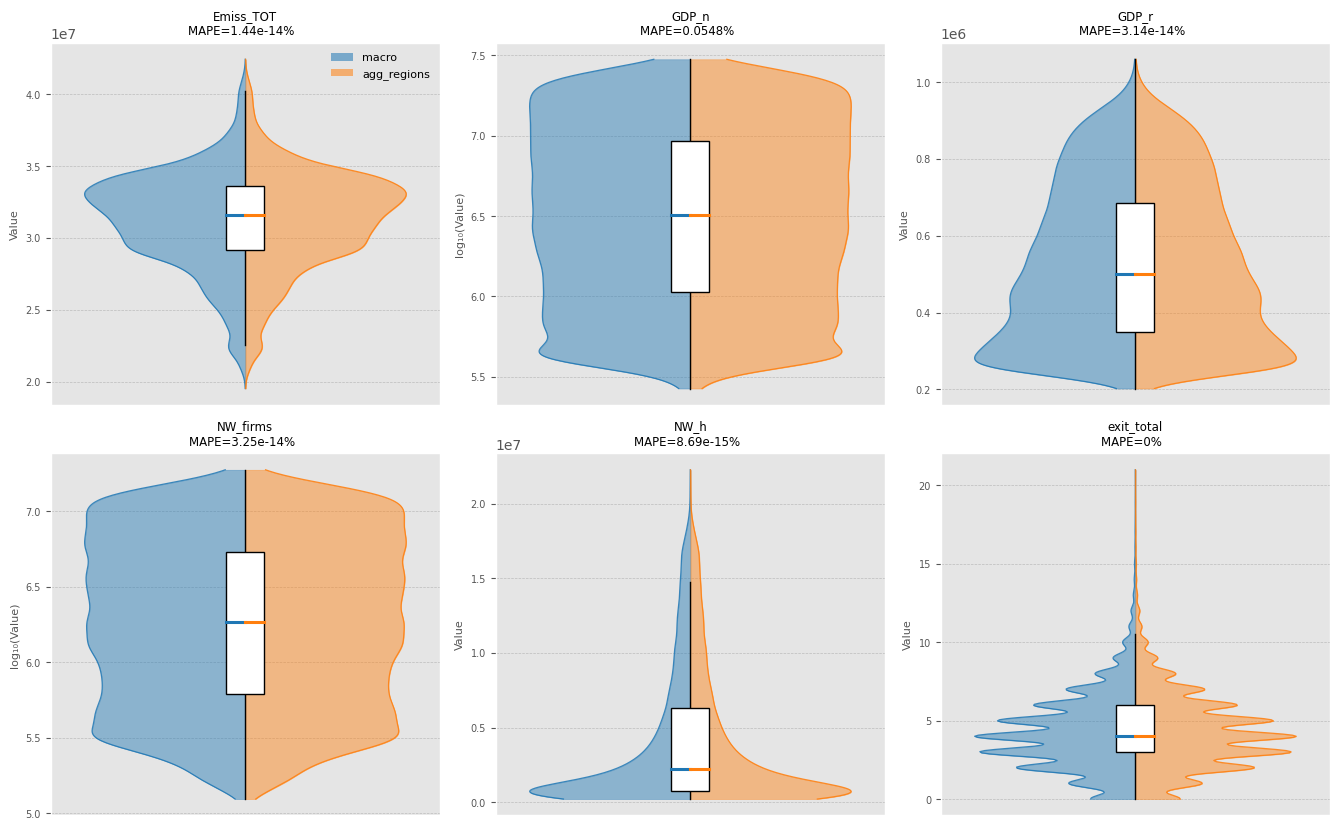

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  30000  3.422300e-10  4.472087e-09  6.134487e-09   
1       GDP_n  30000 -3.292331e+03  3.292345e+03  5.635978e+03   
2       GDP_r  30000  5.335702e-13  1.629640e-10  2.213796e-10   
3    NW_firms  30000  4.349810e-11  1.138140e-09  2.134325e-09   
4        NW_h  30000  5.267211e-11  3.145193e-10  7.211319e-10   
5  exit_total  30000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.435990e-14     1.910619e-13   1.0        1.000000  0.055874   
1      5.478091e-02     3.320033e-01   1.0        0.951991 -0.719723   
2      3.141118e-14     3.933948e-13   1.0        1.000000  0.002410   
3      3.253178e-14     2.053966e-13   1.0        1.000000  0.020384   
4      8.694827e-15     8.703602e-14   1.0        1.000000  0.073235   
5      0.000000e+00     0.000000e+00   1.0        1.000000  0.000000   

   ks_pvalue  close_ratio  passe

In [235]:
check_regional_consistency(
    scenario_results['hrhs_3'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = OUTPUT / "regional_consistency_LPEF.pdf"
)